## 데이터의 특성 파악
- 기초통계량 확인하기
    - 중심화 경향 (평균, 최빈값, 중앙값,분위수)
    - 분포도 (분산, 표준편차, 범위(최대값/최소값))
    - 분포의 형태 (왜도, 첨도)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
dict_data = {
    "이름": "홍길동",
    "나이": 25,
    "거주지": "서울",
    "신체정보": {
        "키": 175.4,
        "몸무게": 71.2
    }, # 한번 더 딕셔너리 있는 경우(중첩데이터)
    "취미": [ # 배열이 있는 경우
        "등산",
        "자전거타기",
        "독서"
    ]
}

In [ ]:
# 딕셔너리 데이터를 데이터프레임으로 불러오기
# 중첩데이터와 배열이 있어 모호하기 때문에 에러가 발생
dict_df = pd.DataFrame(dict_data)

ValueError: Mixing dicts with non-Series may lead to ambiguous ordering.

In [ ]:
# csv파일을 데이터프레임으로 불러오기(read_csv)
file_path = ".csv"
df = pd.read_csv(file_path, encoding='utf-8')

In [ ]:
# json파일을 데이터프레임으로 불러오기(read_json)
file_path = ".json"
df = pd.read_json(file_path, encoding='utf-8')

In [ ]:
# xlsx 파일을 데이프레임으로 불러오기(read_xlsx)
file_path = ".xlsx"
df = pd.read_excel(file_path, encoding='utf-8')

In [ ]:
# 중첩된 데이터를 데이터 프레임으로 불러오기
# 딕셔너리 데이터의 경우에는 별도의 변수화
# 리스트 데이터의 경우에는 평탄화 작업 수행

# 표준화(normalize 해주는 것: '취미'가 평탄화 해야하는 것, meta는 그 데이터의 정보 구성(나머지)/
#                                         신체정보와 키, 신체정보와 몸무게 sep으로 연결 )
df = pd.json_normalize(dict_data, record_path='취미',
                       meta = ['이름', '나이', '거주지',
                                ['신체정보', '키'], ['신체정보', '몸무게']], # 중첩데이터는 배열로 정의
                       sep='_')

# 평탄화 : 배열을 일열로 붙여주는 형태
# 컬럼의 이름 변경
df.rename(columns={0: '취미'}, inplace=True)
df

,취미,이름,나이,거주지,신체정보_키,신체정보_몸무게
0,등산,홍길동,25,서울,175.4,71.2
1,자전거타기,홍길동,25,서울,175.4,71.2
2,독서,홍길동,25,서울,175.4,71.2


In [ ]:
# 중첩된 데이터가 있는 json파일, 데이터 프레임으로 불러오기
file_path = ".json"
with open(file_path, "r") as file:
    data = pd.read_json(file, encoding='utf-8')

df = pd.json_normalize(dict_data, record_path='',
                       meta =[],
                       sep='_')

In [ ]:
# 데이터프레임의 정보 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   취미        3 non-null      object
 1   이름        3 non-null      object
 2   나이        3 non-null      object
 3   거주지       3 non-null      object
 4   신체정보_키    3 non-null      object
 5   신체정보_몸무게  3 non-null      object
dtypes: object(6)
memory usage: 276.0+ bytes


In [ ]:
# 데이터의 기초 통계정보 확인 # min max 표준편차등(숫자형에 대해)
df.describe()

,취미,이름,나이,거주지,신체정보_키,신체정보_몸무게
count,3,3,3,3,3.0,3.0
unique,3,1,1,1,1.0,1.0
top,등산,홍길동,25,서울,175.4,71.2
freq,1,3,3,3,3.0,3.0


In [ ]:
# 숫자형 변수 컬럼명만 가져오기
numeric_columns = df.select_dtypes(include=['number']).columns
# 문자형 변수 컬럼명만 가져오기
string_columns = df.select_dtypes(exclude=['number']).columns
numeric_columns, string_columns

(Index([], dtype='object'),
 Index(['취미', '이름', '나이', '거주지', '신체정보_키', '신체정보_몸무게'], dtype='object'))

In [ ]:
# 숫자형 변수만 선택하여 새로운 데이터프레임 만들기
df_numeric = df.select_dtypes(include='number')

In [ ]:
# decribe()에 표현되지 않는 수치형 데이터의 최빈값, 중앙값, 분산 확인하기
df.mode()
df.median()
df.var()

In [ ]:
# 문자형 변수의 unique값 확인
for column in string_columns:
    print({'컬럼명':column, '고유값의 개수':len(df[column].unique())})

In [ ]:
# 왜도와 첨도 확인하기
# 왜도 0: 대칭
# 왜도 양수: 오른쪽 꼬리가 길고 왼쪽으로 치우침
# 왜도 음수 : 왼쪽 꼬리가 길고 오른쪽으로 치우침
df.skew()

# 첨도
# 정규분포의 첨도는 0
# 뾰족한 분포 : 양수
# 완만한 분포 : 음수
df.kurt()

In [ ]:
# 결측치의 개수 확인하기
# 결측치 인지 아닌지 isna() -> true, false로 나옴 (true = 1, false = 0)
missing_value = df.isna().sum()

In [ ]:
# seaborn에서 제공하는 taxis 데이터 가져오기
df = sns.load_dataset('taxis')

In [ ]:
# 정보 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[ns]
 1   dropoff          6433 non-null   datetime64[ns]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   object        
 9   payment          6389 non-null   object        
 10  pickup_zone      6407 non-null   object        
 11  dropoff_zone     6388 non-null   object        
 12  pickup_borough   6407 non-null   object        
 13  dropoff_borough  6388 non-null   object        
dtypes: datetime64[ns](2), float64(5), int64(

In [ ]:
# 처음 5개 행의 데이터 확인
df.head()
# 마지막 5개 확인
df.tail()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn
6432,2019-03-13 19:31:22,2019-03-13 19:48:02,1,3.85,15.0,3.36,0.0,20.16,green,credit card,Boerum Hill,Windsor Terrace,Brooklyn,Brooklyn


In [ ]:
# 기초통계량 확인
df.describe()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total
count,6433,6433,6433.000000,6433.000000,6433.000000,6433.00000,6433.000000,6433.000000
mean,2019-03-16 08:31:28.514223616,2019-03-16 08:45:49.491217408,1.539251,3.024617,13.091073,1.97922,0.325273,18.517794
min,2019-02-28 23:29:03,2019-02-28 23:32:35,0.000000,0.000000,1.000000,0.00000,0.000000,1.300000
25%,2019-03-08 15:50:34,2019-03-08 16:12:51,1.000000,0.980000,6.500000,0.00000,0.000000,10.800000
50%,2019-03-15 21:46:58,2019-03-15 22:06:44,1.000000,1.640000,9.500000,1.70000,0.000000,14.160000
75%,2019-03-23 17:41:38,2019-03-23 17:51:56,2.000000,3.210000,15.000000,2.80000,0.000000,20.300000
max,2019-03-31 23:43:45,2019-04-01 00:13:58,6.000000,36.700000,150.000000,33.20000,24.020000,174.820000
std,NaN,NaN,1.203768,3.827867,11.551804,2.44856,1.415267,13.815570


In [ ]:
# 숫자형 컬럼만
# number로 해주면 int float에 상관없이 가져옴
numeric_columns = df.select_dtypes(include='number').columns
# 문자형 컬럼만
string_columns = df.select_dtypes(exclude='number').columns

numeric_columns, string_columns

(Index(['passengers', 'distance', 'fare', 'tip', 'tolls', 'total'], dtype='object'),
 Index(['pickup', 'dropoff', 'color', 'payment', 'pickup_zone', 'dropoff_zone',
        'pickup_borough', 'dropoff_borough'],
       dtype='object'))

In [ ]:
# 숫자형 컬럼에 대한 최빈값, 분산 확인
for c in numeric_columns :
    print({"컬럼명" : c,
           "최빈값" : df[c].mode()[0], # mode()라는 함수는 많은 정보를 포함하므로[0]
           "분산": df[c].var()})

{'컬럼명': 'passengers', '최빈값': 1, '분산': 1.4490577096640629}
{'컬럼명': 'distance', '최빈값': 0.8, '분산': 14.652565777434717}
{'컬럼명': 'fare', '최빈값': 7.5, '분산': 133.4441818095617}
{'컬럼명': 'tip', '최빈값': 0.0, '분산': 5.9954440737928785}
{'컬럼명': 'tolls', '최빈값': 0.0, '분산': 2.002981614772268}
{'컬럼명': 'total', '최빈값': 9.3, '분산': 190.86997555962333}


In [ ]:
# 문자형 컬럼의 고유값 확인
for c in string_columns :
    print({'컬럼명' : c,
           '고유값의 개수' : len(df[c].unique()),
           '고유값' : df[c].unique()})

{'컬럼명': 'pickup', '고유값의 개수': 6414, '고유값': <DatetimeArray>
['2019-03-23 20:21:09', '2019-03-04 16:11:55', '2019-03-27 17:53:01',
 '2019-03-10 01:23:59', '2019-03-30 13:27:42', '2019-03-11 10:37:23',
 '2019-03-26 21:07:31', '2019-03-22 12:47:13', '2019-03-23 11:48:50',
 '2019-03-08 16:18:37',
 ...
 '2019-03-12 08:10:47', '2019-03-30 20:52:15', '2019-03-07 15:34:30',
 '2019-03-28 08:04:47', '2019-03-23 18:26:09', '2019-03-31 09:51:53',
 '2019-03-31 17:38:00', '2019-03-23 22:55:18', '2019-03-04 10:09:25',
 '2019-03-13 19:31:22']
Length: 6414, dtype: datetime64[ns]}
{'컬럼명': 'dropoff', '고유값의 개수': 6425, '고유값': <DatetimeArray>
['2019-03-23 20:27:24', '2019-03-04 16:19:00', '2019-03-27 18:00:25',
 '2019-03-10 01:49:51', '2019-03-30 13:37:14', '2019-03-11 10:47:31',
 '2019-03-26 21:17:29', '2019-03-22 12:58:17', '2019-03-23 12:06:14',
 '2019-03-08 16:26:57',
 ...
 '2019-03-12 08:35:35', '2019-03-30 20:59:55', '2019-03-07 16:31:06',
 '2019-03-28 08:07:46', '2019-03-23 18:49:12', '2019-03-31 09:55

In [ ]:
# 왜도와 첨도 (숫자형만 가능)
for c in numeric_columns:
    print({'컬럼명' : c,
           '왜도' : df[c].skew(), # 다 양수이므로 왼쪽으로 치우쳐있다.
           '첨도' : df[c].kurt()}) # 양수이므로 정규분포보다 뾰족하다

{'컬럼명': 'passengers', '왜도': 2.3591434589875453, '첨도': 4.886070487012141}
{'컬럼명': 'distance', '왜도': 3.0082057890318215, '첨도': 11.144463794439298}
{'컬럼명': 'fare', '왜도': 3.217462794607763, '첨도': 17.66337592424149}
{'컬럼명': 'tip', '왜도': 2.665151563396707, '첨도': 12.750449014686655}
{'컬럼명': 'tolls', '왜도': 5.074935611676601, '첨도': 35.470566099472116}
{'컬럼명': 'total', '왜도': 3.0933326288688754, '첨도': 15.065716540715325}


In [ ]:
# 결측치
df.isna().sum()

,0
pickup,0
dropoff,0
passengers,0
distance,0
fare,0
tip,0
tolls,0
total,0
color,0
payment,44


- 시각화를 통해 데이터의 특성 파악하기
    - 분포의 형태 : 히스토그램, 라인그래프, 파이차트
    - 이상치 확인 : 산점도, 박스플롯


Text(0.5, 1.0, 'total')

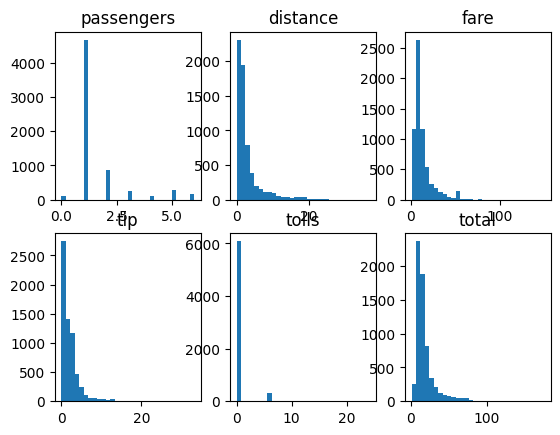

In [ ]:
# 히스토그램
plt.subplot(2,3,1) # 결측치 없는 6개
plt.hist(df['passengers'], bins = 30) #이산형 데이터
plt.title('passengers')
plt.subplot(2,3,2)
plt.hist(df['distance'], bins = 30) # 연속형
plt.title('distance')
plt.subplot(2,3,3)
plt.hist(df['fare'], bins = 30) # 연속형
plt.title('fare')
plt.subplot(2,3,4)
plt.hist(df['tip'], bins = 30) # 연속형
plt.title('tip')
plt.subplot(2,3,5)
plt.hist(df['tolls'], bins = 30) # 이산형
plt.title('tolls')
plt.subplot(2,3,6)
plt.hist(df['total'], bins = 30)
plt.title('total')
# 왼쪽으로 치우쳐있는 것도 확인할 수 있음

([<matplotlib.patches.Wedge at 0x795239457a50>,
 [Text(0.855467201622472, -0.691502615286607, 'credit card'),
  Text(-0.855467136879321, 0.6915026953812236, 'cash')])

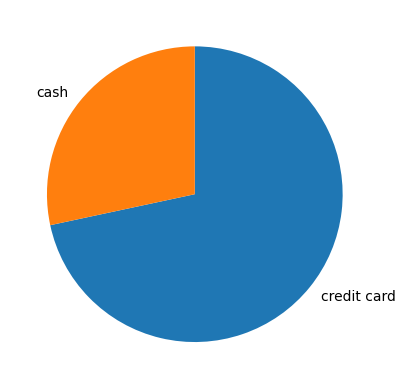

In [ ]:
# 파이차트 - 범주형 데이터
# 파이차트는 값의 개수를 가지고 그림
payment_count = df['payment'].value_counts()
payment_label = payment_count.index
plt.pie(payment_count, labels = payment_label, startangle = 90, counterclock = False)

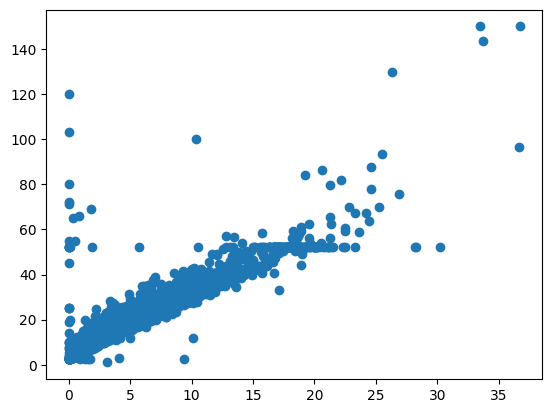

In [ ]:
# 산점도
plt.scatter(x=df['distance'],y=df['fare'])
# 점이 모여있기 때문에 상관관계가 있는 것으로 분석/ 이상치 존재

{'whiskers': [<matplotlib.lines.Line2D at 0x795239024390>,
 'caps': [<matplotlib.lines.Line2D at 0x7952390257d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7952391c9d90>,
 'medians': [<matplotlib.lines.Line2D at 0x795239026a90>,
 'fliers': [<matplotlib.lines.Line2D at 0x7952390272d0>,
 'means': []}

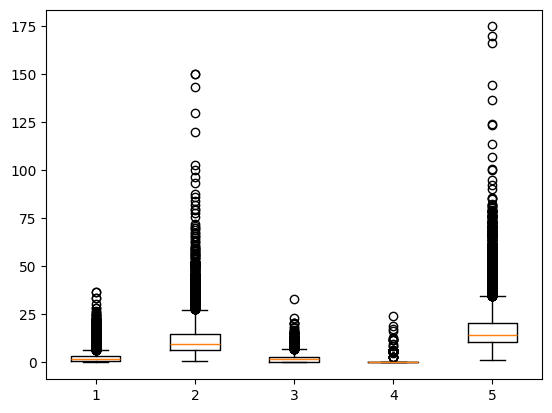

In [ ]:
# 박스플롯
# 이상치가 많아 보임 (위에 산점도에서도 봤을 때 몰려있는 경우도 있지만 위에 동떨어져있는 부분도 있음)
plt.boxplot([df['distance'], df['fare'], df['tip'], df['tolls'], df['total']])

<Axes: >

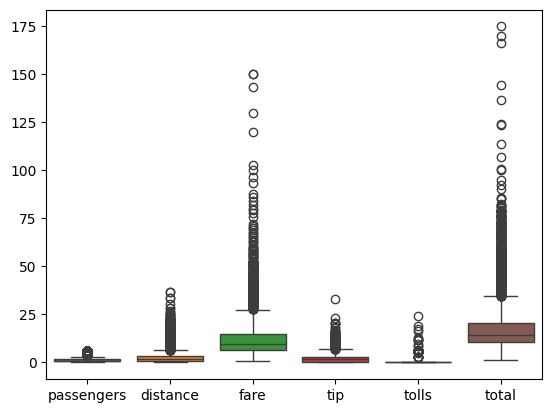

In [ ]:
# 숫자형 컬럼에 대해 데이터 프레임을 만들고 대한 박스 플롯, seaborn을 사용하겠다.
df_numeric = df.select_dtypes(include='number')
sns.boxplot(df_numeric)

{'whiskers': [<matplotlib.lines.Line2D at 0x795238f73390>,
 'caps': [<matplotlib.lines.Line2D at 0x795238f80910>,
 'boxes': [<matplotlib.lines.Line2D at 0x795238f72990>,
 'medians': [<matplotlib.lines.Line2D at 0x795238f82250>,
 'fliers': [<matplotlib.lines.Line2D at 0x795238f51410>,
 'means': []}

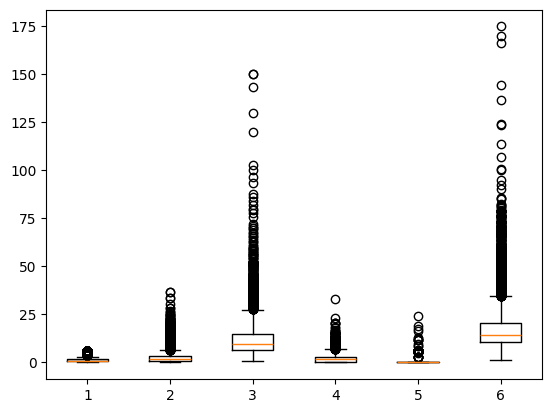

In [ ]:
# 두칸 위의 것도 아예 df로 만들고 boxplot을 만들 수 있지 않을까? 가능!
plt.boxplot(df_numeric)

In [ ]:
 # 분석 과정 및 절차
 # 1. 분석의 목적과 변수가 무엇인지 개별변수의 이름이나 설명을 가지는 지 확인
 # 2. 데이터의 문제성 확인 (결측치 유무, 이상치 유무, 분포의 형태 확인)
 # 3. 데이터의 개별 속성값이 예상한 범위 분포를 가지는지 확인
 # 4. 관계 속성 확인, 데이터의 속성이 아닌 변수간 관계 속성 확인
 # 5. 발견된 문제를 바탕으로 데이터 정제

In [ ]:
# 자료의 특성? 이 자료는 택시 승객들의 요금 데이터이다.
#           승차거리(distance), 요금(fare), tip, tolls, total(fare+tip+tolls)
# 결측치 있는가? 네 (payment 44, pickup_zone 26, dropoff_zone 45, pickup_borough 36, dropoff_borough 45)
# 이상치 있는가? 있다고 보여지지만 연장선상에 있는 큰 값이기 때문에 잘 모르겠음.
# 데이터가 모두 범위안에 있는가? 숫자형은 모두 0 이상으로 괜찮음
# 분포의 형태는? distance, fare, total의 경우 왼쪽으로 치우쳐 있음
# 승차거리와 요금간의 양의 상관관계 있음
# 데이터의 단위는? 모두 비용이라 단위 동일
# 이제 데이터 정제해보자.

## 변수 변환 (데이터 변환)

## Scikit-learn (sklearn) 라이브러리
- 머신러닝(Machine Learning) 라이브러리
- 다양한 머신러닝 알고리즘, 모델 학습, 평가, 데이터 전처리 및 하이퍼파라미터 튜닝 등 전체 머신러닝 워크플로우를 지원
- https://scikit-learn.org

In [ ]:
# !pip install sklearn #colab은 이미 설치되어있어 import만
import sklearn

## Scipy 라이브러리 (Scientific Computing Library)
- 과학적 계산과 수치적 작업을 지원하는 라이브러리
- NumPy를 기반으로 하여 수치적 계산을 지원하며, 다양한 과학적, 수학적 작업을 위한 고급 기능을 제공
- https://scipy.org/

In [ ]:
# !pip install scipy
import scipy

### 결측치 처리

In [ ]:
# 결측치 제거
df_cleaned = df.dropna()

In [ ]:
# 결측치 대체 (평균)
value = df['Value'].mean()
df_filled = df.fillna(value)

In [ ]:
# 결측치 대체 (이전/이후값) - 시계열 데이터
# 이전값 ffill
df['Value'] = df['Value'].fillna(method='ffill') # forwardfill

# 이후값 bfill
df['Value'] = df['Value'].fillna(method='bfill')

* 결측치 있는가? 네 <br>
(payment 44, pickup_zone
26, dropoff_zone 45, pickup_borough 36, dropoff_borough 45)

In [ ]:
df['payment'].dropna(inplace=True) # drop되지 않음
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[ns]
 1   dropoff          6433 non-null   datetime64[ns]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   object        
 9   payment          6389 non-null   object        
 10  pickup_zone      6407 non-null   object        
 11  dropoff_zone     6388 non-null   object        
 12  pickup_borough   6407 non-null   object        
 13  dropoff_borough  6388 non-null   object        
dtypes: datetime64[ns](2), float64(5), int64(

In [ ]:
# 결측치 처리(payment - 제거) 제거된 것을 알 수 있음
# 제거해서 새로운 df_cleaned 만듬
df_cleaned = df.dropna(subset=['payment'])
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6389 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6389 non-null   datetime64[ns]
 1   dropoff          6389 non-null   datetime64[ns]
 2   passengers       6389 non-null   int64         
 3   distance         6389 non-null   float64       
 4   fare             6389 non-null   float64       
 5   tip              6389 non-null   float64       
 6   tolls            6389 non-null   float64       
 7   total            6389 non-null   float64       
 8   color            6389 non-null   object        
 9   payment          6389 non-null   object        
 10  pickup_zone      6364 non-null   object        
 11  dropoff_zone     6345 non-null   object        
 12  pickup_borough   6364 non-null   object        
 13  dropoff_borough  6345 non-null   object        
dtypes: datetime64[ns](2), float64(5), int64(1), o

In [ ]:
# 결측치 처리(pickup_borough26, dropoff_borough 45)
# 둘 다 비어있는 경우 제거
df_cleaned.dropna(subset=['pickup_borough', 'dropoff_borough'], how='all', inplace = True)
# dropoff에 대해서 pickup의 값으로 대체
# pickup과 distance 를 고려하여 dropoff에 대한 예측값으로 대체

df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6368 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6368 non-null   datetime64[ns]
 1   dropoff          6368 non-null   datetime64[ns]
 2   passengers       6368 non-null   int64         
 3   distance         6368 non-null   float64       
 4   fare             6368 non-null   float64       
 5   tip              6368 non-null   float64       
 6   tolls            6368 non-null   float64       
 7   total            6368 non-null   float64       
 8   color            6368 non-null   object        
 9   payment          6368 non-null   object        
 10  pickup_zone      6364 non-null   object        
 11  dropoff_zone     6345 non-null   object        
 12  pickup_borough   6364 non-null   object        
 13  dropoff_borough  6345 non-null   object        
dtypes: datetime64[ns](2), float64(5), int64(1), o

<ipython-input-6-0aabd834f472>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned.dropna(subset=['pickup_borough', 'dropoff_borough'], how='all', inplace = True)


In [ ]:
# 2) 대체
#   - dropoff에 대해서 pickup의 값으로 대체
#   - 이전값 / 이후값으로 대체
#   - 최빈값으로 대체

df_cleaned['dropoff_borough'].fillna(df_cleaned['pickup_borough'], inplace=True)
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6368 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6368 non-null   datetime64[ns]
 1   dropoff          6368 non-null   datetime64[ns]
 2   passengers       6368 non-null   int64         
 3   distance         6368 non-null   float64       
 4   fare             6368 non-null   float64       
 5   tip              6368 non-null   float64       
 6   tolls            6368 non-null   float64       
 7   total            6368 non-null   float64       
 8   color            6368 non-null   object        
 9   payment          6368 non-null   object        
 10  pickup_zone      6364 non-null   object        
 11  dropoff_zone     6345 non-null   object        
 12  pickup_borough   6364 non-null   object        
 13  dropoff_borough  6368 non-null   object        
dtypes: datetime64[ns](2), float64(5), int64(1), o

<ipython-input-7-8144d6bd3550>:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cleaned['dropoff_borough'].fillna(df_cleaned['pickup_borough'], inplace=True)
<ipython-input-7-8144d6bd3550>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['dropoff_borough'].fillna(df_cleaned['pickup_borough'], inplace=True)


In [ ]:
df_cleaned.dropna(subset=['pickup_borough'], inplace=True)
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6364 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6364 non-null   datetime64[ns]
 1   dropoff          6364 non-null   datetime64[ns]
 2   passengers       6364 non-null   int64         
 3   distance         6364 non-null   float64       
 4   fare             6364 non-null   float64       
 5   tip              6364 non-null   float64       
 6   tolls            6364 non-null   float64       
 7   total            6364 non-null   float64       
 8   color            6364 non-null   object        
 9   payment          6364 non-null   object        
 10  pickup_zone      6364 non-null   object        
 11  dropoff_zone     6341 non-null   object        
 12  pickup_borough   6364 non-null   object        
 13  dropoff_borough  6364 non-null   object        
dtypes: datetime64[ns](2), float64(5), int64(1), o

<ipython-input-8-f6ad797188c9>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned.dropna(subset=['pickup_borough'], inplace=True)


In [ ]:
df_cleaned['dropoff_zone'].fillna(df_cleaned['pickup_zone'], inplace=True)
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6364 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6364 non-null   datetime64[ns]
 1   dropoff          6364 non-null   datetime64[ns]
 2   passengers       6364 non-null   int64         
 3   distance         6364 non-null   float64       
 4   fare             6364 non-null   float64       
 5   tip              6364 non-null   float64       
 6   tolls            6364 non-null   float64       
 7   total            6364 non-null   float64       
 8   color            6364 non-null   object        
 9   payment          6364 non-null   object        
 10  pickup_zone      6364 non-null   object        
 11  dropoff_zone     6364 non-null   object        
 12  pickup_borough   6364 non-null   object        
 13  dropoff_borough  6364 non-null   object        
dtypes: datetime64[ns](2), float64(5), int64(1), o

<ipython-input-10-34d15e3c130d>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['dropoff_zone'].fillna(df_cleaned['pickup_zone'], inplace=True)


### 이상치 처리
- IQR(Interquartile Range)
    - 중간 50% 데이터의 범위 (Q3-Q1)
    - 이상치 : IQR을 기준으로 1.5배 IQR 범위를 벗어난 데이터
- Z-score
    - 표준화 스코어, 평균에서 얼마나 떨어져 있는지를 지표화
    - 이상치 : 절대값이 3보다 큰 데이터


In [ ]:
# IQR기반 이상치 제거
# IQR 계산
Q1 = df['Value'].quantile(0.25)
Q3 = df['Value'].quantile(0.75)
IQR = Q3 - Q1

# 이상치 경계값 계산
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 이상치 제거
df_no_outliers = df[(df['Value'] >= lower_bound) & (df['Value'] <= upper_bound)]

In [ ]:
# df['value의 z-score'] = (df['value'] - df[value]. mean()) / df[value].std()

In [ ]:
# z-score 기반 이상치 제거
from scipy import stats

# Z-Score 계산
z_scores = stats.zscore(df['Value'])

# 이상치 경계값 설정 (Z-Score가 3보다 크거나 -3보다 작은 값은 이상치로 간주)
df_no_outliers = df[(z_scores < 3) & (z_scores > -3)]

In [ ]:
# 이상치 대체 (평균)
import numpy as np

# 이상치를 제외한 평균 데이터 계산
mean_value = df[(df['Value'] >= lower_bound) & (df['Value'] <= upper_bound)]['Value'].mean()

# 이상치 대체
df['Value'] = np.where((df['Value'] < lower_bound) | (df['Value'] > upper_bound), mean_value, df['Value'])

In [ ]:
# 이상치 대체 (하위 경계값, 상위 경계값)
df['Value'] = np.where((df['Value'] < lower_bound), lower_bound, df['Value'])

df['Value'] = np.where((df['Value'] > upper_bound), upper_bound, df['Value'])

In [ ]:
# 이상치 대체 (이전값, 이후값) - 시계열 데이터
# 이전값
df['Value'] = df['Value'].where((df['Value'] >= lower_bound) & (df['Value'] <= upper_bound), method='ffill')

# 이후값
df['Value'] = df['Value'].where((df['Value'] >= lower_bound) & (df['Value'] <= upper_bound), method='bfill')

In [ ]:
# 이상치 유무 확인(개수)
from scipy import stats
# z-score 계산
df_cleaned_numeric = df_cleaned.select_dtypes(include = 'number')
z_scores = stats.zscore(df_cleaned_numeric)
z_scores # 아직 값을 변환해준게 다여서 어디에 개수가 있는지 확인 불가

# 이상치 개수 확인
# 절대값이 3보다 개수
outlier_count = (np.abs(z_scores) > 3).sum()
outlier_count

# 택시 데이터에서 distance 많이 간 승객, 승객 1명을 태운 횟수 : 이런건 이상치라고 못함(계산엔 포함이 되어있음)
# 간 거리가 0인데 돈을 낸 경우나 긴 거리를 갔는데 돈을 많이 내지 않은 경우는 이상치라고 할 수 있음!

,0
passengers,153
distance,193
fare,197
tip,153
tolls,337
total,181


In [ ]:
# 택시 데이터에서 distance 많이 간 승객, 승객 1명을 태운 횟수 : 이런건 이상치라고 못함(계산엔 포함이 되어있음)
# 간 거리가 0인데 돈을 낸 경우나 긴 거리를 갔는데 돈을 많이 내지 않은 경우는 이상치라고 할 수 있음!
# -> 확인
df_cleaned[(df_cleaned['distance'] == 0) & (df_cleaned['fare'] != 0)].head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
120,2019-03-21 17:21:44,2019-03-21 17:21:49,1,0.0,2.5,0.00,0.0,4.30,yellow,cash,JFK Airport,JFK Airport,Queens,Queens
670,2019-03-08 04:50:48,2019-03-08 04:51:07,1,0.0,2.5,0.00,0.0,6.30,yellow,cash,Lenox Hill East,Lenox Hill East,Manhattan,Manhattan
1080,2019-03-04 14:17:05,2019-03-04 14:17:13,1,0.0,2.5,0.00,0.0,3.30,yellow,cash,JFK Airport,JFK Airport,Queens,Queens
1482,2019-03-10 20:27:25,2019-03-10 20:28:33,1,0.0,52.0,16.59,0.0,71.89,yellow,credit card,Lincoln Square East,Lincoln Square East,Manhattan,Manhattan
1910,2019-03-25 14:37:56,2019-03-25 14:38:22,1,0.0,2.5,0.01,0.0,3.31,yellow,credit card,Queensbridge/Ravenswood,Queensbridge/Ravenswood,Queens,Queens


- 이상치 처리
  - 거리가 길면, 요금이 증가하므로 이는 보존
  - tip, tolls은 발생할 때와 아닌 경우의 차이가 크므로 보존
  - passengers는 1~2가 평균이고 승객의 수는 많아도 상관없으므로 보존
  - 거리가 0인데 비용을 지불한 경우는 제거

In [ ]:
# 거리가 0인데 비용을 지불한 경우 제외
df_no_outliers = df_cleaned[(df_cleaned['distance'] != 0) | (df_cleaned['fare'] == 0)]
df_no_outliers.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6329 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6329 non-null   datetime64[ns]
 1   dropoff          6329 non-null   datetime64[ns]
 2   passengers       6329 non-null   int64         
 3   distance         6329 non-null   float64       
 4   fare             6329 non-null   float64       
 5   tip              6329 non-null   float64       
 6   tolls            6329 non-null   float64       
 7   total            6329 non-null   float64       
 8   color            6329 non-null   object        
 9   payment          6329 non-null   object        
 10  pickup_zone      6329 non-null   object        
 11  dropoff_zone     6329 non-null   object        
 12  pickup_borough   6329 non-null   object        
 13  dropoff_borough  6329 non-null   object        
dtypes: datetime64[ns](2), float64(5), int64(1), o

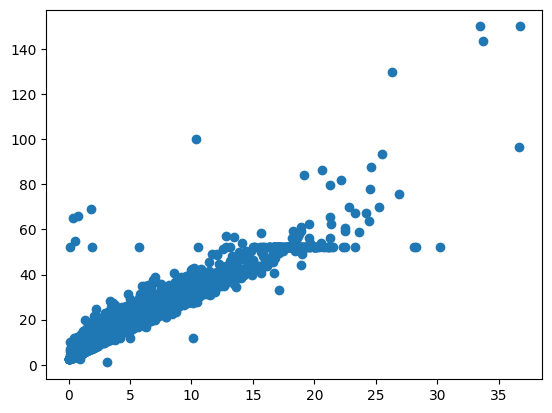

In [ ]:
plt.scatter(x=df_no_outliers['distance'], y=df_no_outliers['fare'])
# 전과 비교해 조금 튀는 데이터들이 사라지는 것을 볼 수 있음

### 범주화

In [ ]:
# 구간을 나누어 범주화후 라벨링
ages = [15, 23, 35, 42, 19, 28, 33, 51, 62, 18, 20, 41]
bins=[0, 20, 40, 60, 80]
labels=['청소년', '청년', '중년', '장년']
age_groups = pd.cut(ages, bins=bins, labels=labels)
age_groups

['청소년', '청년', '청년', '중년', '청소년', ..., '중년', '장년', '청소년', '청소년', '중년']
Length: 12
Categories (4, object): ['청소년' < '청년' < '중년' < '장년']

In [ ]:
# 구간을 나누어 구간의 인덱스로 변환
age_groups = np.digitize(ages, bins)
age_groups

array([1, 2, 2, 3, 1, 2, 2, 3, 4, 1, 2, 3])

- 승하차 시간에 대해 시간대로 카테고리화

In [ ]:
# 시간대를 범주화하기

# 1) 탑승 시간 정보 추가(승하차 시간)
df_no_outliers['ride_hour'] = ((df_no_outliers['pickup'].dt.hour) + (df_no_outliers['dropoff'].dt.hour)) / 2 # datetime의 hour를 가져와
df_no_outliers.head()
# 2) 시간대를 범주화
bins = [0, 6, 12, 18, 24]
labels = ['새벽', '오전', '오후', '저녁']

df_no_outliers['ride_hour_category'] = pd.cut(df_no_outliers['ride_hour'], bins=bins, labels=labels)
df_no_outliers.head()

<ipython-input-31-fa826779b75f>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_outliers['ride_hour'] = ((df_no_outliers['pickup'].dt.hour) + (df_no_outliers['dropoff'].dt.hour)) / 2 # datetime의 hour를 가져와
<ipython-input-31-fa826779b75f>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_outliers['ride_hour_category'] = pd.cut(df_no_outliers['ride_hour'], bins=bins, labels=labels)


,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough,ride_hour,ride_hour_category
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan,20.0,저녁
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan,16.0,오후
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan,17.5,오후
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan,1.0,새벽
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan,13.0,오후


### 정규화 (상대적 특성 완화)

In [ ]:
# Min-Max 정규화
# 어떤 (value 값 - value의 min)/(max-min)
df['Min_Max_Scaled'] = (df['Value'] - df['Value'].min()) / (df['Value'].max() - df['Value'].min())

In [ ]:
# Min-Max 정규화
from sklearn.preprocessing import MinMaxScaler
# Min-Max Scaler 적용
scaler = MinMaxScaler()
df['Normalized'] = scaler.fit_transform(df[['Value']])

In [ ]:
help(sklearn.preprocessing.MinMaxScaler) # 궁금할 때

Help on class MinMaxScaler in module sklearn.preprocessing._data:

class MinMaxScaler(sklearn.base.OneToOneFeatureMixin, sklearn.base.TransformerMixin, sklearn.base.BaseEstimator)
 |  MinMaxScaler(feature_range=(0, 1), *, copy=True, clip=False)
 |  
 |  Transform features by scaling each feature to a given range.
 |  
 |  This estimator scales and translates each feature individually such
 |  that it is in the given range on the training set, e.g. between
 |  zero and one.
 |  
 |  The transformation is given by::
 |  
 |      X_std = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))
 |      X_scaled = X_std * (max - min) + min
 |  
 |  where min, max = feature_range.
 |  
 |  This transformation is often used as an alternative to zero mean,
 |  unit variance scaling.
 |  
 |  `MinMaxScaler` doesn't reduce the effect of outliers, but it linearly
 |  scales them down into a fixed range, where the largest occurring data point
 |  corresponds to the maximum value and the smallest one 

In [ ]:
# z-score 정규화
df['Z_Score_Scaled'] = stats.zscore(df['Value'])

# 여러 컬럼에 대해 Z-Score 정규화
df_zscore = df.apply(stats.zscore)
# 위와 같음
#df_zscore = stats.zscore(df)

In [ ]:
from sklearn.preprocessing import StandardScaler
# Z-Score 표준화 적용
scaler = StandardScaler()
df['Standardized'] = scaler.fit_transform(df[['price']])

- 택시 데이터는 단위가 동일하여 정규화 하지 않음

### 정규분포화(분포의 치우침 완화)

In [ ]:
# 로그변환
df['Log_price'] = np.log(df['price'])

In [ ]:
# 역수변환
df['Inverse_Value'] = 1 / df['Value']

In [ ]:
# 지수변환
df['Exp_Value'] = np.exp(df['Value'])
df['Squared_Value'] = np.power(df['Value'], 2)
df['Squared_Value'] = np.power(df['Value'], 3)

In [ ]:
# 제곱근변환
df['SquareRoot_Value'] = np.sqrt(df['Value'])

In [ ]:
# 왜도 체크
check_skew = ['distance', 'fare', 'total']
for c in check_skew:
    print({'컬럼명' : c,
           '왜도' : df_no_outliers[c].skew()})

{'컬럼명': 'distance', '왜도': 3.007916084835987}
{'컬럼명': 'fare', '왜도': 3.1691779971445104}
{'컬럼명': 'total', '왜도': 2.9921373737828514}


- 왜도 완화
  - 0 : 대칭
  - -1 < 왜도 < 0 : 분포가 약간 오른쪽으로 치우쳐있음(right skewed, positive skew) -> **2
  - 0 < 왜도 < 1 : 분포가 약간 왼쪽으로 치우쳐 있음 -> sqrt  
  - -2 < 왜도 < -1 : 중간정도로 오른쪽으로 치우친 분포 -> **3
  - 1 < 왜도 < 2 : 중간정도로 왼쪽으로 치우친 분포 -> log
  - 왜도 > 2 : 분포가 왼쪽으로 많이 치우친 분포 -> 역수 변환
  - 왜도 < -2 : 분포가 오른쪽으로 많이 치우친 분포 -> 지수

- 택시 데이터는 왼쪽으로 많이 치우친 분포이다
  - distance만 루트변환
  - fare나 total은 보존 (total = fare + tip + tolls 이므로 모두 계산 다시해줘야하기 때문)

In [ ]:
df_no_outliers['distance_root'] = np.sqrt(df_no_outliers['distance']) # 별도의 컬럼으로 만들어줌
df_no_outliers['distance_root'].skew() # 위의 3.xxx 보다 작아짐

<ipython-input-35-19799f022785>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_outliers['distance_root'] = np.sqrt(df_no_outliers['distance']) # 별도의 컬럼으로 만들어줌


1.703436167117978

(array([9.00e+00, 3.60e+01, 2.12e+02, 7.09e+02, 1.14e+03, 1.06e+03,
        7.93e+02, 5.57e+02, 4.02e+02, 2.84e+02, 2.14e+02, 1.33e+02,
        1.33e+02, 9.00e+01, 1.09e+02, 1.16e+02, 6.60e+01, 4.60e+01,
        3.80e+01, 3.00e+01, 5.80e+01, 5.00e+01, 2.00e+01, 9.00e+00,
        6.00e+00, 2.00e+00, 2.00e+00, 1.00e+00, 2.00e+00, 2.00e+00]),
 array([0.1       , 0.29860175, 0.4972035 , 0.69580525, 0.894407  ,
        1.09300875, 1.2916105 , 1.49021225, 1.688814  , 1.88741575,
        2.0860175 , 2.28461925, 2.483221  , 2.68182275, 2.8804245 ,
        3.07902625, 3.277628  , 3.47622975, 3.6748315 , 3.87343325,
        4.07203499, 4.27063674, 4.46923849, 4.66784024, 4.86644199,
        5.06504374, 5.26364549, 5.46224724, 5.66084899, 5.85945074,
        6.05805249]),
 <BarContainer object of 30 artists>)

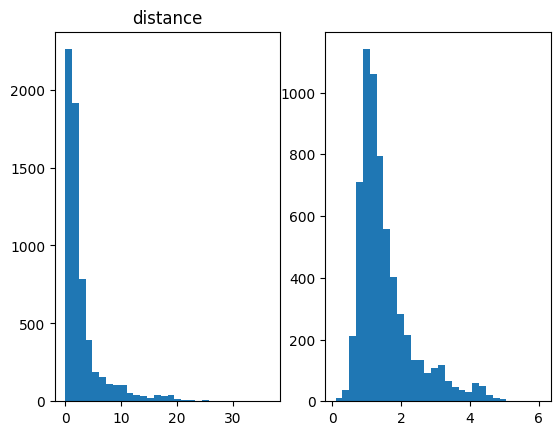

In [ ]:
plt.subplot (1,2,1)
plt.hist(df_no_outliers['distance'], bins=30)
plt.title('distance')
plt.subplot(1,2,2)
plt.hist(df_no_outliers['distance_root'], bins=30)

### 인코딩(범주형 데이터를 수치형 데이터로 변환)

In [ ]:
# 범주를 고유한 정수로 변환
df['Category_encoded'], unique = pd.factorize(df['Category'])

In [ ]:
# 범주를 지정된 라벨로 변환
category_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df['Category_encoded'] = df['Category'].map(category_mapping)

In [ ]:
# 원핫인코딩
df_one_hot = pd.get_dummies(df, columns=['Category'])

In [ ]:
# 라벨 인코딩
from sklearn.preprocessing import LabelEncoder
# LabelEncoder 객체 생성
label_encoder = LabelEncoder()

# 'Category'열에 Label Encoding 적용
df['Category_encoded'] = label_encoder.fit_transform(df['Category'])

In [ ]:
# 원핫 인코딩
from sklearn.preprocessing import OneHotEncoder

# OneHotEncoder 객체 생성
encoder = OneHotEncoder(sparse=False)  # sparse=False로 하면 배열 형태로 결과를 반환

# 데이터를 fit_transform()을 통해 변환
encoded_data = encoder.fit_transform(df[['Category']]).toarray()

# 결과를 DataFrame으로 변환
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(['Category']))

# 원본 DataFrame과 인코딩된 DataFrame을 합침
df = pd.concat([df, encoded_df], axis=1)

print(encoded_df)

In [ ]:
# ride_hour_category에 대해 원핫인코딩으로 변환
df_one_hot = pd.get_dummies(df_no_outliers, columns = ['ride_hour_category'])
df_one_hot.head()
# 새벽 오전 오후 저녁에 대해 어떤 상태인지 true false로 표시

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough,ride_hour,distance_root,ride_hour_category_새벽,ride_hour_category_오전,ride_hour_category_오후,ride_hour_category_저녁
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan,20.0,1.264911,False,False,False,True
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan,16.0,0.888819,False,False,True,False
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan,17.5,1.170470,False,False,True,False
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan,1.0,2.774887,True,False,False,False
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan,13.0,1.469694,False,False,True,False


In [ ]:
# 원핫 인코딩
from sklearn.preprocessing import OneHotEncoder

# OneHotEncoder 객체 생성
encoder = OneHotEncoder()  # sparse=False로 하면 배열 형태로 결과를 반환

# 데이터를 fit_transform()을 통해 변환
encoded_data = encoder.fit_transform(df_no_outliers[['ride_hour_category']]).toarray()

# 결과를 DataFrame으로 변환
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(['ride_hour_category']))

# 원본 DataFrame과 인코딩된 DataFrame을 합침
df_one_hot = pd.concat([df_no_outliers, encoded_df], axis=1)

print(encoded_data)
df_one_hot.head()

[[0. 0. 0. 1. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0.]
 ...
 [0. 0. 0. 1. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0.]]


## [실습] 농산물가격예측을 위해 수집한 데이터에 대해 데이터 정제
- 품목 가격정보 > 배추
- 서울시 기온
- 서울시 강수량
- 소비자물가지수
- 수출입동향
1. 위의 5개의 파일을 읽어오기
2. 데이터의 특성 파악 (기초통계, 산포도, 분포형태)
    - 기초 통계량
    - 결측치 여부
    - 이상치 여부
    - 왜도/첨도
3. 분석에 용이한 데이터로 변환
    - 결측치 제거
    - 이상치 처리
    - 범주화/정규화(데이터, 분포)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


- 배추 가격 정보

In [ ]:
# 배추 가격 정보
df_price = pd.read_excel('/content/drive/MyDrive/(day27)10조 데이터 수집/배추가격정보.xlsx')
df_price.head()

,구분,2024년,2023년,2022년,2021년,2020년,2019년,평년
0,01월,3043,2952,4228,3027,4608,2626,3402
1,02월,3457,3047,4089,3804,4366,2464,3647
2,03월,3673,3497,4451,4736,4343,2252,4097
3,04월,4402,3923,4978,5211,4508,2271,4470
4,05월,3814,4069,4634,3736,4793,2364,4146


In [ ]:
# 가격정보 열과 행을 조합하여 하나의 열로 변환
df_price = pd.melt(df_price, id_vars=['구분 '], var_name='Year', value_name='Value')
df_price

,구분,Year,Value
0,01월,2024년,3043
1,02월,2024년,3457
2,03월,2024년,3673
3,04월,2024년,4402
4,05월,2024년,3814
...,...,...,...
86,09월,평년,6725
87,10월,평년,6226
88,11월,평년,3718
89,12월,평년,3374


In [ ]:
# 기본 정보 확인
df_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91 entries, 0 to 90
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   구분      91 non-null     object
 1   Year    91 non-null     object
 2   Value   91 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 2.3+ KB


In [ ]:
# 왜도 확인
df_price['Value'].skew() # 왜도가 0보다 크므로 왼쪽으로 치우침, 오른쪽으로 긴 꼬리

1.534864592317082

In [ ]:
# 첨도 확인
df_price['Value'].kurt() # 첨도 3보다 큼 뾰족한 형태

3.3948389918358823

In [ ]:
# 결측치 확인(결측치 없음)
df_price.isna().sum()

,0
구분,0
Year,0
Value,0


In [ ]:
# 연도별 평균 값
df_price.groupby('Year')['Value'].mean()

,Value
Year,
2019년,3533.076923
2020년,5289.000000
2021년,4151.153846
2022년,5013.461538
2023년,4069.538462
2024년,4792.307692
평년,4431.538462


In [ ]:
df_price_2024 = df_price[df_price['Year']=='2024년'].drop('Year', axis=1)
df_price_2023 = df_price[df_price['Year']=='2023년'].drop('Year', axis=1)
df_price_2022 = df_price[df_price['Year']=='2022년'].drop('Year', axis=1)
df_price_2021 = df_price[df_price['Year']=='2021년'].drop('Year', axis=1)
df_price_2020 = df_price[df_price['Year']=='2020년'].drop('Year', axis=1)

df_price_2024

,구분,Value
0,01월,3043
1,02월,3457
2,03월,3673
3,04월,4402
4,05월,3814
5,06월,3560
6,07월,4824
7,08월,6397
8,09월,8172
9,10월,8240


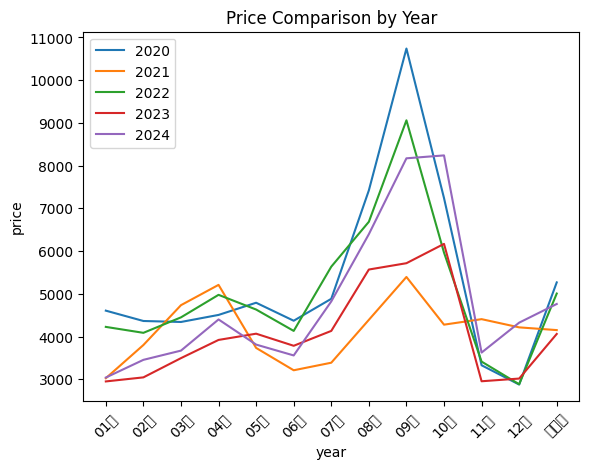

In [ ]:
# 선 그래프 그리기
plt.plot(df_price_2020['구분 '], df_price_2020['Value'], label='2020') # x축, y축 , 라벨링
plt.plot(df_price_2021['구분 '], df_price_2021['Value'], label='2021')
plt.plot(df_price_2022['구분 '], df_price_2022['Value'], label='2022')
plt.plot(df_price_2023['구분 '], df_price_2023['Value'], label='2023')
plt.plot(df_price_2024['구분 '], df_price_2024['Value'], label='2024')

# x축과 y축 레이블 설정
plt.xlabel('year')
plt.ylabel('price')

# 그래프 제목 설정
plt.title('Price Comparison by Year')

# 라벨 기반 범례 추가
plt.legend(loc = 'upper left')

# 그래프 출력
plt.show()

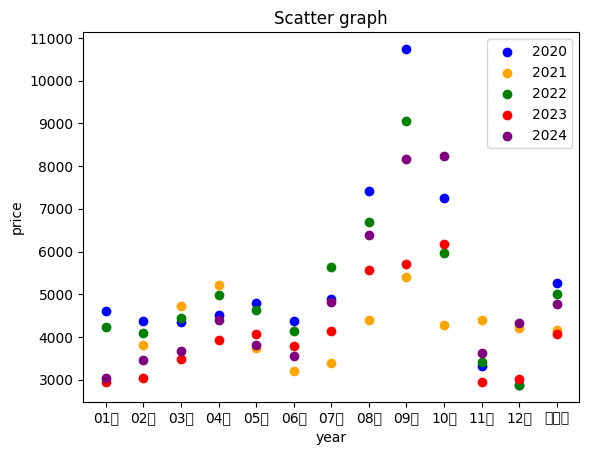

In [ ]:
# 산점도
plt.scatter(df_price_2020['구분 '], df_price_2020['Value'], label='2020', color = 'blue') # x축, y축 , 라벨링
plt.scatter(df_price_2021['구분 '], df_price_2021['Value'], label='2021', color = 'orange')
plt.scatter(df_price_2022['구분 '], df_price_2022['Value'], label='2022', color = 'green')
plt.scatter(df_price_2023['구분 '], df_price_2023['Value'], label='2023', color = 'red')
plt.scatter(x=df_price_2024['구분 '],y=df_price_2024['Value'], label = 2024, color = 'purple')

plt.xlabel('year')
plt.ylabel('price')

plt.title('Scatter graph')

plt.legend()

plt.show()

# 점이 모여있기 때문에 상관관계가 있는 것으로 분석/ 이상치 존재

- 소비자 물가지수

In [ ]:
# 소비자 물가지수
df_retail_price = pd.read_csv('/content/drive/MyDrive/(day27)10조 데이터 수집/서울시 소비자물가지수(품목성질별 2020~2024).csv', encoding = 'utf-8', index_col = '시점')
df_retail_price.head()

,소계,농축수산물,공업제품,전기·수도·가스,집세,공공서비스,개인서비스
시점,,,,,,,
2020. 01,106.09,115.77,102.89,88.98,106.32,102.20,111.26
2020. 02,106.06,114.81,103.09,88.98,106.40,102.05,111.21
2020. 03,105.97,115.96,102.59,88.98,106.50,101.85,111.18
2020. 04,105.55,116.78,101.54,88.98,106.58,100.70,111.20
2020. 05,105.32,114.88,101.41,88.98,106.74,100.57,110.92


In [ ]:
df_retail_price.info()

<class 'pandas.core.frame.DataFrame'>
Index: 60 entries, 2020. 01 to 2024. 12
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   소계        60 non-null     float64
 1   농축수산물     60 non-null     float64
 2   공업제품      60 non-null     float64
 3   전기·수도·가스  60 non-null     float64
 4   집세        60 non-null     float64
 5   공공서비스     60 non-null     float64
 6   개인서비스     60 non-null     float64
dtypes: float64(7)
memory usage: 3.8+ KB


In [ ]:
df_retail_price.describe()

,소계,농축수산물,공업제품,전기·수도·가스,집세,공공서비스,개인서비스
count,60.000000,60.000000,60.00000,60.000000,60.000000,60.000000,60.000000
mean,108.848167,119.775000,107.58000,112.358667,105.297000,102.254333,112.517667
std,3.099860,7.447086,4.35945,24.889129,1.992382,2.631121,3.273065
min,103.320000,107.720000,101.41000,79.020000,102.680000,94.590000,103.770000
25%,106.082500,112.360000,103.12000,85.832500,103.832500,100.385000,111.130000
50%,108.045000,120.295000,107.83500,109.310000,104.305000,101.665000,112.605000
75%,112.005000,125.455000,112.17750,138.975000,107.030000,105.152500,114.640000
max,114.240000,134.430000,113.99000,145.350000,109.520000,106.300000,117.790000


In [ ]:
df_retail_price.skew() # 0에 가까움 정규분포와 비슷

,0
소계,0.354378
농축수산물,0.115429
공업제품,0.022333
전기·수도·가스,0.002418
집세,0.617149
공공서비스,0.038798
개인서비스,-0.627684


In [ ]:
df_retail_price.kurt() # 평평한 그래프

,0
소계,-1.174931
농축수산물,-1.225119
공업제품,-1.627969
전기·수도·가스,-1.758187
집세,-1.080403
공공서비스,-0.301073
개인서비스,0.270120


- 월별 강수량

In [ ]:
# 월별 강수량
df_rainfall = pd.read_csv('/content/drive/MyDrive/(day27)10조 데이터 수집/서울시 월별 강수량(2020~2024).csv',
                          encoding = 'cp949', index_col ='년월')
df_rainfall.head()

,지점,강수량(mm)
년월,,
20-Jan,108,60.5
20-Feb,108,53.1
20-Mar,108,16.3
20-Apr,108,16.9
20-May,108,112.4


In [ ]:
df_rainfall.info()

<class 'pandas.core.frame.DataFrame'>
Index: 60 entries, 20-Jan to 24-Dec
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   지점       60 non-null     int64  
 1   강수량(mm)  60 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 1.4+ KB


In [ ]:
df_rainfall.describe()

,지점,강수량(mm)
count,60.0,60.000000
mean,108.0,125.385000
std,0.0,145.288538
min,108.0,0.000000
25%,108.0,20.025000
50%,108.0,85.200000
75%,108.0,146.825000
max,108.0,675.700000


In [ ]:
# 왜도
df_rainfall.skew()

,0
지점,0.000000
강수량(mm),2.121278


In [ ]:
# 첨도
df_rainfall.kurt()

,0
지점,0.000000
강수량(mm),4.696479


In [ ]:
df_rainfall = df_rainfall.drop('지점', axis =1) # 지점이 같은 숫자만 반복되므로 삭제
df_rainfall.head()

,강수량(mm)
년월,
20-Jan,60.5
20-Feb,53.1
20-Mar,16.3
20-Apr,16.9
20-May,112.4


In [ ]:
plt.plot(df_rainfall['년월'], df_rainfall['강수량(mm)'])
plt.xlabel('year-month')
plt.ylabel('rainfall')
plt.show()

KeyError: '년월'

- 월별 평균기온

In [ ]:
# 월별평균기온
df_avg_temp = pd.read_csv('/content/drive/MyDrive/(day27)10조 데이터 수집/서울시 월별 평균기온(2020~2024).csv',
                          encoding = 'cp949')
df_avg_temp.head()

,\t\t지점번호,지점명,일시,평균기온(℃),평균최고기온(℃),최고기온(℃),\t최고기온일자,평균최저기온(℃),최저기온(℃),최저기온일자
0,\t\t108,서울,20-Jan,1.6,5.9,11.9,2020-01-26,-1.7,-6.5,2020-01-01
1,\t\t108,서울,20-Feb,2.5,7.2,15.6,2020-02-15,-1.3,-11.8,2020-02-06
2,\t\t108,서울,20-Mar,7.7,13.3,20.6,2020-03-26,2.6,-2.8,2020-03-05
3,\t\t108,서울,20-Apr,11.1,16.6,23.8,2020-04-16,6.3,1.9,2020-04-05
4,\t\t108,서울,20-May,18.0,23.3,30.0,2020-05-30,13.7,9.2,2020-05-20


In [ ]:
# 수출입 동향
df_trade = pd.read_excel('/content/drive/MyDrive/(day27)10조 데이터 수집/수출입동향.xlsx')
df_trade

,구분1,구분2,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,수출,소계,6183,6104,6465,6827,6926,7025,7564,8558,8824,9157
1,수출,농산물,5224,5221,5581,6047,5985,6146,6675,7543,7714,7994
2,수출,축산물,470,497,458,341,417,460,496,551,602,621
3,수출,임산물,489,387,425,439,524,418,393,464,508,407
4,수입,소계,31635,30221,29673,32294,35302,34304,34279,41905,48571,43816
5,수입,농산물,19308,17902,17666,18594,19903,19876,20669,25289,29764,27288
6,수입,축산물,5622,5728,5807,6603,7522,7786,7627,9177,10997,10150
7,수입,임산물,6704,6592,6200,7097,7877,6642,5983,7439,7811,6378
8,무역수지,무역수지,-25453,-24117,-23208,-25467,-28376,-27279,-26715,-33346,-39747,-34659
